# Лекция  библиотека **Matplotlib**

Ресурсы для дальнейшего изучения:

Официальная документация Matplotlib: https://matplotlib.org/

Галерея примеров Matplotlib: https://matplotlib.org/stable/gallery/index.html

Marker reference:
https://matplotlib.org/stable/gallery/lines_bars_and_markers/marker_reference.html#sphx-glr-gallery-lines-bars-and-markers-marker-reference-py

Документация ipywidgets: https://ipywidgets.readthedocs.io/en/stable/

Документация Seaborn: https://seaborn.pydata.org/

**Matplotlib**– это одна из самых популярных библиотек для визуализации данных в Python. Она предоставляет широкий набор инструментов для создания графиков, диаграмм, гистограмм и других визуализаций.

**Цели лекции:**

* Познакомиться с основными компонентами Matplotlib: pyplot, figure, axes, plot.
* Научиться создавать базовые типы графиков: линейные графики, точечные диаграммы, гистограммы, столбчатые диаграммы.
* Научиться настраивать внешний вид графиков: заголовки, метки осей, легенды, цвета, стили линий, маркеры.
* Рассмотри Matplotlib для визуализации данных о пассажирах “Титаника” и выявления интересных закономерностей.

# Установка и импорт Matplotlib

In [24]:
# Установка (если еще не установлена)
# pip install matplotlib

# Импорт
import matplotlib.pyplot as plt  #  для  отображения графиков
import pandas as pd              # для работы  с df
import numpy as np               # для работы с массивами

# Дополнительно, для красивого отображения графиков в Jupyter Notebook
# %matplotlib inline
# (Альтернатива: %matplotlib notebook для интерактивных графиков)

погрузим базу titanic.csv

In [25]:
# Используем pandas для загрузки данных
titanic_df = pd.read_excel('titanic.xlsx', sheet_name='1',) # Укажите путь к вашему файлу
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### обозначение столбцов титаник

**PassengerId:** Уникальный идентификатор пассажира. (Числовой, целое число)

**Survived:** Показывает, выжил пассажир (1) или нет (0). (Категориальный, 0 или 1)

**Pclass:** Класс каюты пассажира (1 = 1st, 2 = 2nd, 3 = 3rd). Представляет собой социально-экономический статус. (Категориальный, числовой: 1, 2 или 3)

**Name:** Имя пассажира. (Текстовый)

**Sex:** Пол пассажира (male - мужской, female - женский). (Категориальный, текстовый)

**Age:** Возраст пассажира в годах. Значения могут быть дробными. Если возраст неизвестен, то значение отсутствует (NaN). (Числовой, вещественное число)

**SibSp:** Количество братьев, сестер и супругов на борту Титаника. (Числовой, целое число)

**Parch**: Количество родителей и детей на борту Титаника. (Числовой, целое число)

**Ticket**: Номер билета. (Текстовый, может содержать цифры и буквы)

**Fare**: Стоимость билета. (Числовой, вещественное число)

**Cabin**: Номер каюты пассажира. Многие значения отсутствуют (NaN). (Текстовый)

**Embarked:** Порт посадки пассажира (C = Cherbourg, Q = Queenstown, S = Southampton). (Категориальный, текстовый)


Важные моменты:

Отсутствующие данные: Столбцы Age и Cabin содержат отсутствующие значения (NaN - Not a Number). Это важно учитывать при анализе и подготовке данных для машинного обучения.
Категориальные признаки: Столбцы Sex, Pclass и Embarked являются категориальными. Для использования в моделях машинного обучения их часто необходимо преобразовать в числовые представления (например, с помощью one-hot encoding).
Столбцы SibSp и Parch: Эти столбцы можно объединить для создания нового признака “FamilySize” (размер семьи).

Анализируя  графики вместе, можно получить комплексное представление о данных о “Титанике”, выявить факторы, которые влияли на выживание пассажиров, и сделать интересные выводы о социальной структуре пассажиров на корабле.

## **Основные компоненты Matplotlib**

**pyplot:** Модуль, предоставляющий простой интерфейс для создания графиков. Он содержит функции для создания и управления фигурами, осями, линиями и другими элементами графиков. Обычно импортируется как **plt.**

**Figure:** Контейнер верхнего уровня, представляющий весь график. Он может содержать несколько Axes.

**Axes**: Область рисования, где отображаются данные. Axes содержит оси (X, Y, Z для 3D) и другие элементы, такие как заголовки, метки осей, легенды и т.д.

**Plot:** Функция для рисования линий или точек на Axes. Это основная функция для создания линейных графиков и точечных диаграмм.

**Дополнительные советы:**

* Не перегружайте график: Используйте настройки внешнего вида умеренно, чтобы график оставался читаемым и понятным.

* Используйте осмысленные подписи: Давайте линиям понятные имена, чтобы их можно было легко идентифицировать на графике.

* Экспериментируйте: Не бойтесь экспериментировать с разными параметрами, чтобы найти наилучший способ представления ваших данных.

 # Регулировки размера графика в Matplotlib

##  Размер всей фигуры (Figure)

Это наиболее распространенный способ управления размером графика. Вы указываете размер фигуры в дюймах (inches) при ее создании. Это влияет на общие пропорции и размер всех элементов графика.

**figsize** - принимает кортеж (ширина, высота) в дюймах.

Изменение figsize повлияет на размер всех элементов графика: осей, линий, текста, маркеров и т.д.

Размеры в дюймах соответствуют размеру графика при печати или сохранении в файл с разрешением 100 DPI (dots per inch).

In [ ]:
# Создаем фигуру с заданным размером (ширина = 8 дюймов, высота = 6 дюймов)
fig = plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [4, 5, 2])
plt.show()

In [ ]:
# Или более короткий вариант (рекомендуется):
fig, ax = plt.subplots(figsize=(12, 9))

# Теперь добавляем графики (axes) на фигуру и рисуем на них
ax.plot([1, 2, 3], [4, 5, 2])
plt.show()

## DPI (Dots Per Inch)

**DPI (Dots Per Inch):**- определяет разрешение изображения. Увеличение DPI увеличивает количество пикселей на дюйм, что делает изображение более четким, но также увеличивает размер файла. DPI влияет на размер графика при сохранении в файл.

* По умолчанию Matplotlib использует DPI = 100.
* Увеличение DPI увеличивает размер сохраненного изображения, но не меняет размер графика, отображаемого на экране.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([1, 2, 3], [4, 5, 2])

# Сохраняем график с разрешением 300 DPI
plt.savefig('my_plot.png', dpi=300)  #Чем больше DPI, тем больше размер файла.

plt.show()

## Размер осей (Axes):

* add_axes([left, bottom, width, height]) создает новые оси.

* left и bottom указывают положение левого нижнего угла осей относительно левого нижнего угла фигуры (значения от 0 до 1).
* width и height указывают ширину и высоту осей относительно ширины и высоты фигуры (значения от 0 до 1).

In [ ]:
fig = plt.figure()

# Добавляем оси в координатах (left, bottom, width, height), где значения от 0 до 1
# Относительно размера фигуры.
ax = fig.add_axes([0.1, 0.1, 0.5, 0.5]) # 10% от левого края, 10% от нижнего, 80% ширина, 80% высота

ax.plot([1, 2, 3], [4, 5, 2])
plt.show()

* **tight_layout():**
Автоматически регулирует параметры подграфиков, чтобы обеспечить размещение графиков в фигуре без перекрытий. Это полезно, когда у вас несколько подграфиков или когда вы настраиваете размер шрифта и меток.

In [ ]:

# Создаем фигуру и оси (сетку 2x2)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8)) #  nrows=2 и ncols=2 задают сетку из 2 строк и 2 столбцов для размещения графиков.

# Данные для графиков
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = x**2
y4 = np.exp(-x)

# Рисуем графики на разных осях
axes[0, 0].plot(x, y1, color='blue')    # axes[0, 0] обращается к осям, расположенным в первой строке и первом столбце сетки.
axes[0, 0].set_title('Синус')    # индувидиальное название графика

axes[0, 1].plot(x, y2, color='red')
axes[0, 1].set_title('Косинус')

axes[1, 0].plot(x, y3, color='green')
axes[1, 0].set_title('Квадрат')

axes[1, 1].plot(x, y4, color='purple')
axes[1, 1].set_title('Экспонента')

# Добавляем общие метки осей (по желанию)
fig.supxlabel("X-axis")                #Общая подпись по оси X
fig.supylabel("Y-axis")                #Общая подпись по оси Y

# Подгоняем расположение графиков
plt.tight_layout()                     # Без этой строки графики могут перекрываться

# Добавляем общий заголовок (тоже может перекрываться, если не использовать tight_layout)
fig.suptitle("Примеры графиков", fontsize=16)

plt.show()

###### Создадим 2*3

In [ ]:
# Создаем фигуру и оси (сетку 2x2)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10)) #  nrows=2 и ncols=2 задают сетку из 2 строк и 2 столбцов для размещения графиков.

# Данные для графиков
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = x**2
y4 = np.exp(-x)

# Рисуем графики на разных осях
axes[0, 0].plot(x, y1, color='blue')    # axes[0, 0] обращается к осям, расположенным в первой строке и первом столбце сетки.
axes[0, 0].set_title('Синус')    # индувидиальное название графика

axes[0, 1].plot(x, y2, color='red')
axes[0, 1].set_title('Косинус')

axes[1, 0].plot(x, y3, color='green')
axes[1, 0].set_title('Квадрат')

axes[1, 1].plot(x, y4, color='purple')
axes[1, 1].set_title('Экспонента')

axes[2, 0].plot(x, y3, color='green')
axes[2, 0].set_title('Квадрат')

axes[2, 1].plot(x, y4, color='purple')
axes[2, 1].set_title('Экспонента')

# Добавляем общие метки осей (по желанию)
fig.supxlabel("X-axis")                #Общая подпись по оси X
fig.supylabel("Y-axis")                #Общая подпись по оси Y

# Подгоняем расположение графиков
                     # Без этой строки графики могут перекрываться

# Добавляем общий заголовок (тоже может перекрываться, если не использовать tight_layout)
fig.suptitle("Примеры графиков", fontsize=16)

plt.tight_layout()
plt.show()

 ## Регулировка отступов (margins) ручная регулировка


Вы можете вручную регулировать отступы вокруг графика, используя subplots_adjust():

* left, bottom, right, top задают отступы от соответствующих сторон фигуры.

* Значения находятся в диапазоне от 0 до 1 и задают долю от размера фигуры.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([1, 2, 3], [4, 5, 2])

plt.subplots_adjust(left=0.25, bottom=0.05, right=0.85, top=0.50) #отступы в долях от размера фигуры
plt.show()

 # Базовые типы графиков

## Линейные графики (plot)

**Основные параметры**
* x: Массив значений для оси X.
* y: Массив значений для оси Y.
* format_string: (Необязательный) Строка форматирования, определяющая цвет, маркер и тип линии.
* **kwargs: (Необязательный) Дополнительные аргументы ключевого слова для настройки внешнего вида графика.

**Настройка внешнего вида с использованием format_string:**

Формат: '**[маркер][тип линии][цвет]**'. Порядок важен!



In [ ]:
'''
#Маркеры:
'.' - точка (point)
',' - пиксель (pixel)
'o' - круг (circle)
'v' - треугольник вниз (triangle down)
'^' - треугольник вверх (triangle up)
'<' - треугольник влево (triangle left)
'>' - треугольник вправо (triangle right)
'1' - треножник вниз (tri down)
'2' - треножник вверх (tri up)
'3' - треножник влево (tri left)
'4' - треножник вправо (tri right)
's' - квадрат (square)
'p' - пятиугольник (pentagon)
'*' - звезда (star)
'h' - шестиугольник 1 (hexagon1)
'H' - шестиугольник 2 (hexagon2)
'+' - плюс (plus)
'x' - крест (x)
'D' - ромб (diamond)
'd' - тонкий ромб (thin diamond)
'|' - вертикальная линия (vline)
'_' - горизонтальная линия (hline)
'''

In [ ]:
# Типы линий:
'''
'-' - сплошная линия (solid line)
'--' - пунктирная линия (dashed line)
'-.' - штрих-пунктирная линия (dash-dot line)
':' - точечная линия (dotted line)
'''

In [ ]:
'''
#Цвета:
'b' - синий (blue)
'g' - зеленый (green)
'r' - красный (red)
'c' - голубой (cyan)
'm' - пурпурный (magenta)
'y' - желтый (yellow)
'k' - черный (black)
'w' - белый (white)
'''

In [ ]:
# Пример:  простой линейный график
x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 3, 5]

plt.plot(x, y)  # наш обьект plt запускает функцию plot (линейная) с аргументами x и у
#plt.plot(x, y, 'D:y')
plt.xlabel("X")  # надпись по Х
plt.ylabel("Y")   #  надпись по y
plt.title("Линейный график")  # надпись названия
plt.show()     # обьект plt запусти метод показа

Настройка внешнего вида с использованием **kwargs:

Параметр **kwargs позволяет более детально настроить внешний вид линии.


Сочетание **format_string и **kwargs:**

Можно комбинировать **format_string и **kwargs**, но ****kwargs** переопределят параметры, указанные в format_string.

In [ ]:

'''
color: Цвет линии (можно использовать название цвета, HEX-код, RGB-значения).

linestyle: Тип линии (можно использовать строки, как в format_string).

linewidth: Толщина линии в точках (points).

marker: Тип маркера (можно использовать строки, как в format_string).

markersize: Размер маркера в точках.

markeredgecolor: Цвет границы маркера.

markerfacecolor: Цвет заливки маркера.

alpha: Прозрачность линии (от 0 до 1).

label: Подпись для линии (используется в легенде).

solid_capstyle: Определяет стиль концов сплошной линии ('butt', 'round', 'projecting').

dash_capstyle: Определяет стиль концов пунктирной линии ('butt', 'round', 'projecting').

dash_joinstyle: Определяет стиль соединения отрезков пунктирной линии ('miter', 'round', 'bevel').
'''

In [ ]:

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y, color='purple', linestyle='--', linewidth=3, alpha= 0.5, label='Синусоида',marker='H')

plt.xlabel('X')
plt.ylabel('sin(X)')
plt.legend()
plt.title('Линейный график с настройками')
plt.show()

**Примеры настройки capstyle и joinstyle:**

In [ ]:
x = [1, 2, 3, 4]
y = [1, 4, 2, 3]

#plt.plot(x, y, linestyle='--', linewidth=8, dash_capstyle='projecting', dash_joinstyle='round', color = 'blue')
plt.plot(x, y, linestyle='--', linewidth=8, dash_capstyle='round', dash_joinstyle='bevel', color = 'blue')
plt.title("Линия с настройкой dash_capstyle и dash_joinstyle")
plt.show()

## Точечные диаграммы (scatter)

* x: Массив значений для оси X.
* y: Массив значений для оси Y.
* s: Размер маркеров в точках (points squared). Может быть скаляром (один размер для всех точек) или массивом (разный размер для каждой точки).
* c: Цвет маркеров. Может быть:
 * Строкой, представляющей название цвета (например, 'red', '#FF0000').
 * Массивом числовых значений, которые будут отображены с использованием цветовой карты (см. cmap, norm, vmin, vmax).
 * Массивом названий цветов или HEX-кодов.

* marker: Тип маркера (можно использовать значения из matplotlib.markers.MarkerStyle.markers).

* cmap: Цветовая карта, используемая для отображения значений c в цвета.
* norm: Объект matplotlib.colors.Normalize, используемый для масштабирования значений c в диапазон [0, 1] перед отображением с использованием цветовой карты.
* vmin, vmax: Минимальное и максимальное значения, используемые для масштабирования значений c в цветовой карте. Если не указаны, используются минимальное и максимальное значения из c.
* alpha: Прозрачность маркеров (от 0 до 1).
* linewidths: Толщина линий контура маркеров в точках. Может быть скаляром или массивом.
* edgecolors: Цвет линий контура маркеров. Может быть:
Строкой, представляющей название цвета.
Массивом названий цветов или HEX-кодов.
'face' - использовать цвет заливки маркера.
'none' - не отображать контур.
**kwargs: Дополнительные аргументы ключевого слова для настройки внешнего вида графика.

**Из matplotlib.markers.MarkerStyle.markers**

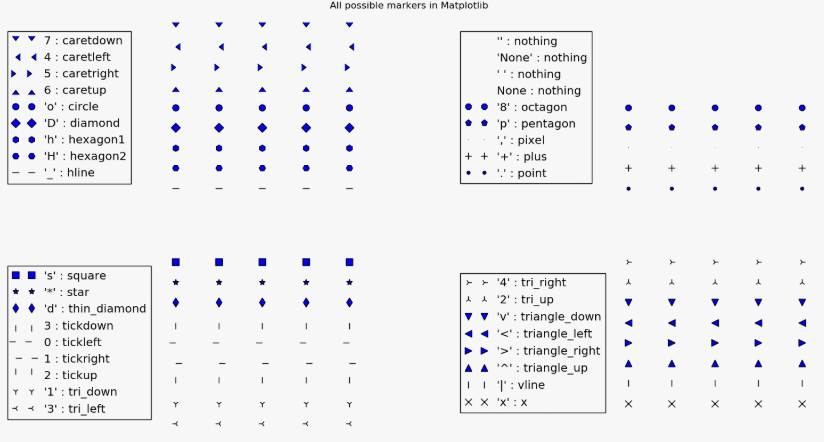

In [ ]:
# Пример: точечная диаграмма
x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 3, 5]

#plt.scatter(x, y)  #  точечная
plt.scatter(x, y, s=None, c='#FF0000', marker=7, cmap=None, norm=None,  alpha=None, linewidths=None, edgecolors=None)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Точечная диаграмма")
plt.show()

In [ ]:
plt.scatter(x, y, marker='x')  # Крестики
plt.scatter(x, y, marker='^')  # Треугольники

In [ ]:
plt.scatter(x, y, s=100, edgecolors='red', linewidths=2) # Красный контур толщиной 2

In [ ]:
assert len(x) == len(y)
sizes = np.random.randint(20, 200, size=len(x)).astype(float)
plt.scatter(x, y, s=sizes)

plt.scatter(x, y, s=80.0)  # один скаляр
mask = x.notna() & y.notna()
x1, y1 = x[mask], y[mask]
sizes = np.random.randint(20, 200, size=len(x1)).astype(float)
plt.scatter(x1, y1, s=sizes)
x = np.ravel(x); y = np.ravel(y)
sizes = np.random.randint(20, 200, size=len(x)).astype(float)
plt.scatter(x, y, s=sizes)


sizes = np.random.randint(20, 200, size=50)
plt.scatter(x, y, s=sizes)

import pandas as pd
x = pd.Series(x)
y = pd.Series(y)

mask = x.notna() & y.notna()
x1, y1 = x[mask].to_numpy(), y[mask].to_numpy()
sizes = np.random.randint(20, 200, size=len(x1)).astype(float)

plt.scatter(x1, y1, s=sizes)


print(len(x), len(y))
print(np.asarray(sizes).shape, np.asarray(sizes).dtype)


In [ ]:
x = np.random.rand(50)
y = np.random.rand(50)

# Размер точек зависит от значения y
sizes = y * 200

# Цвет точек зависит от значения x
colors = x

plt.scatter(x, y, s=sizes, c=colors, cmap='viridis', alpha=0.7, edgecolors='black', linewidths=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Точечная диаграмма с настройкой размера и цвета')
plt.colorbar(label='Значение X')  # Добавляем цветовую шкалу
plt.show()

## Гистограммы (hist)

* x: Обязательный параметр. Массив (или последовательность массивов) данных, для которых строится гистограмма.

* bins: Определяет количество интервалов (столбцов) в гистограмме. Может быть:

 * Целым числом: Задает количество интервалов.
 * Последовательностью: Задает границы интервалов.

* range: Кортеж (min, max), задающий диапазон значений, для которых строится гистограмма. Значения вне этого диапазона игнорируются. Если не указан, используются минимальное и максимальное значения из x.

* density: Если True, гистограмма нормализуется, так что площадь под гистограммой равна 1. Это полезно для сравнения распределений с разным количеством данных. (Ранее параметр назывался normed)

* weights: Массив весов, применяемых к каждому значению в x. Позволяет учитывать вклад каждого значения при построении гистограммы.

* cumulative: Если True, строится кумулятивная гистограмма, которая показывает накопленную частоту значений.

* bottom: Скаляр или массив, задающий базовое положение для каждого столбца гистограммы. Полезно для создания составных гистограмм.

* histtype: Определяет тип гистограммы:

 * 'bar' (по умолчанию): Стандартная столбчатая гистограмма.
 * 'barstacked' : Столбчатая гистограмма, где несколько наборов данных отображаются один над другим.
 *  'step' : Контурная гистограмма.
 * 'stepfilled' : Залитая контурная гистограмма.

* align: Определяет выравнивание столбцов гистограммы:

 * 'left' : Столбцы выравниваются по левому краю.
 * 'mid' (по умолчанию): Столбцы выравниваются по центру.
 * 'right' : Столбцы выравниваются по правому краю.

* orientation: Ориентация гистограммы:

 * 'vertical' (по умолчанию): Вертикальная гистограмма.
 * 'horizontal' : Горизонтальная гистограмма.
rwidth: Относительная ширина столбцов гистограммы (от 0 до 1).

* log: Если True, ось Y отображается в логарифмическом масштабе.

* color: Цвет столбцов гистограммы. Может быть строкой (название цвета) или последовательностью цветов.

* label: Подпись для гистограммы (используется в легенде).

* stacked: Если True, несколько гистограмм отображаются одна над другой (только если передано несколько наборов данных в x).

* **kwargs: Дополнительные аргументы ключевого слова, передаваемые в matplotlib.patches.Rectangle для настройки внешнего вида столбцов гистограммы.

In [ ]:
# Пример: гистограмма
data = np.random.randn(1000)  # Генерируем случайные данные
plt.hist(data, bins=100) # bins - количество столбцов гистограммы -интервалы
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.title("Гистограмма")
plt.show()

In [ ]:
# Пример: гистограмма
data = np.random.randn(1000)  # Генерируем случайные данные
plt.hist(data, bins=30, color='skyblue', edgecolor='black', range=None, density=True , weights=None, cumulative=False, bottom=None, histtype='step', align='mid', orientation='horizontal' , rwidth=None, log=False, label=None, stacked=False)
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.title("Гистограмма")
plt.show()

In [ ]:
# Кумулятивная гистограмма
plt.hist(data, bins=30, cumulative=True, color='lightsteelblue')
plt.xlabel('Значение')
plt.ylabel('Накопленная частота')
plt.title('Кумулятивная гистограмма')
plt.show()

In [ ]:
# Два набора данных на одной гистограмме (stacked)
data1 = np.random.randn(500)
data2 = np.random.randn(500) + 1 # Сдвигаем второе распределение

plt.hist([data1, data2], bins=30, color=['skyblue', 'lightcoral'], label=['Данные 1', 'Данные 2'], stacked=True)
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.title('Два набора данных на одной гистограмме (stacked)')
plt.legend()
plt.show()

## Столбчатые диаграммы (bar, barh)

**Основные параметры plt.bar():**

* x: Обязательный параметр. Позиции столбцов на оси X. Это могут быть числовые значения или строковые метки. Важно, чтобы количество элементов в x соответствовало количеству элементов в height.

* height: Обязательный параметр. Высота столбцов (значения, которые нужно отобразить). Это должен быть числовой массив.

* width: Ширина столбцов. По умолчанию 0.8. Можно задать как одно значение для всех столбцов, так и массив значений для каждого столбца.

* bottom: Базовые позиции для столбцов (значения, от которых начинается отсчет высоты столбцов). По умолчанию None (столбцы начинаются от 0). Полезно для создания составных столбчатых диаграмм (stacked bar charts).

* align: Выравнивание столбцов по позиции x:

 * 'center' (по умолчанию): Столбцы выравниваются по центру позиции x.
 * 'edge': Столбцы выравниваются по краю позиции x. В этом случае нужно также учитывать параметр width, чтобы правильно расположить столбцы.

* data: Объект, из которого берутся данные. Если x и/или height являются строками, они интерпретируются как имена столбцов в этом объекте.

* **kwargs: Дополнительные аргументы ключевого слова для настройки внешнего вида столбцов. Некоторые важные kwargs:

 * color: Цвет столбцов. Может быть строкой (название цвета) или последовательностью цветов.
 * edgecolor: Цвет границы столбцов.
 * linewidth: Толщина линии границы столбцов.
 * linestyle: Стиль линии границы столбцов.
 * alpha: Прозрачность столбцов (от 0 до 1).
 * label: Подпись для столбцов (используется в легенде).
 * hatch: Добавляет штриховку к столбцам. Может принимать значения: '/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'.


In [ ]:
# Данные
categories = ['A', 'B', 'C', 'D']
values = [25, 40, 30, 55]

# Столбчатая диаграмма с базовыми параметрами
plt.bar(categories, values)
plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Столбчатая диаграмма')
plt.show()

In [ ]:
# Разные цвета для каждого столбца
colors = ['red', 'green', 'blue', 'orange'] # ]#
plt.barh(categories, values, color=colors)
plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Столбчатая диаграмма с разными цветами')
plt.show()

In [ ]:
# Использование параметра hatch
plt.bar(categories, values, color='skyblue', hatch='//') #Добавляем штриховку
plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Столбчатая диаграмма со штриховкой')
plt.show()

In [ ]:
# Составная столбчатая диаграмма (stacked bar chart)
values1 = [20, 35, 25, 45]
values2 = [5, 5, 5, 10]

plt.bar(categories, values1, label='Группа 1', color='skyblue',hatch='*')
plt.bar(categories, values2, bottom=values1, label='Группа 2', color='lightcoral' ,hatch='x')  # bottom задает базовую позицию

plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Составная столбчатая диаграмма')
plt.legend()
plt.show()

In [ ]:
# Составная столбчатая диаграмма (stacked bar chart)
values1 = [20, 35, 25, 45]
values2 = [5, 5, 5, 10]

plt.bar(categories, values1, label='Группа 1', hatch='*')
plt.bar(categories, values2, label='Группа 2', hatch='x')  # bottom задает базовую позицию

plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Составная столбчатая диаграмма')
plt.legend()
plt.show()

**Дополнительные настройки меток (для обоих способов):**

* fontsize: Размер шрифта метки.
* color: Цвет метки.
* fontweight: Толщина шрифта метки ('normal', 'bold', 'light', и т.д.).
* rotation: Угол поворота метки (в градусах). Полезно, если метки длинные и могут перекрываться.
* ha (horizontalalignment): Горизонтальное выравнивание метки ('center', 'left', 'right').
* va (verticalalignment): Вертикальное выравнивание метки ('center', 'top', 'bottom').
* fmt : Строка форматирования для меток (например, '%.1f' для отображения с одним знаком после запятой, '{:.0%}' для отображения в процентах).
* labels_type : Определяет, какие значения отображать в метках. Может быть 'edge' (значение высоты столбца) или 'center' (значение, расположенное по центру столбца, если это составная столбчатая диаграмма).

In [ ]:
# Данные
categories = ['A', 'B', 'C', 'D']
values = [25, 40, 30, 55]

# Создаем столбчатую диаграмму
fig, ax = plt.subplots() #Создаем Figure и Axes объекты
bars = ax.bar(categories, values, color='skyblue')

# Добавляем метки на столбцы с помощью bar_label
ax.bar_label(bars, padding=1) #По умолчанию labels не отображаются на графике

plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Столбчатая диаграмма с метками (bar_label)')
plt.show()

In [ ]:
categories = ['A', 'B', 'C', 'D']
values = [25, 40, 30, 55]

# Создаем столбчатую диаграмму
fig, ax = plt.subplots()
bars = ax.bar(categories, values, color='skyblue')

# Добавляем метки с настройками (ax.bar_label)
ax.bar_label(bars, padding=1, fmt='%.1f', fontsize=10, color='navy', rotation = 45) # Форматирование с одним знаком после запятой, размер шрифта, цвет

plt.xlabel('Категории')
plt.ylabel('Значения')
plt.title('Столбчатая диаграмма с настроенными метками')
plt.show()

## Круговые диаграммы (pie)

* x: Обязательный параметр. Массив числовых значений, представляющих размеры секторов круговой диаграммы. Сумма значений в x определяет размер всего круга.

* explode: Массив, определяющий, насколько “выдвинуть” каждый сектор из центра круга. Значения в массиве задают расстояние от центра в долях от радиуса круга. Если None (по умолчанию), все сектора находятся вплотную к центру.

* labels: Список строк, задающих метки для каждого сектора. Метки отображаются рядом с секторами (или внутри них, в зависимости от размера сектора и других параметров).

* colors: Список цветов, используемых для каждого сектора. Если None, используются цвета по умолчанию.

* autopct: Строка форматирования, используемая для отображения процентных значений внутри секторов. Например, '%.1f%%' отображает значения с одним знаком после запятой и знаком процента. Если None, процентные значения не отображаются. Можно передать функцию, которая принимает процент и возвращает отформатированную строку.

* pctdistance: Расстояние от центра круга, на котором отображаются процентные значения (если autopct не None). Значение задается в долях от радиуса круга.

* shadow: Если True, добавляется тень под круговой диаграммой, создавая эффект трехмерности.

* labeldistance: Расстояние от центра круга, на котором отображаются метки секторов (если labels не None). Значение задается в долях от радиуса круга.

* startangle: Угол (в градусах), с которого начинается отрисовка первого сектора. По умолчанию 0 (от 3 часов).

* radius: Радиус круговой диаграммы.

* counterclock: Если True (по умолчанию), сектора отображаются против часовой стрелки. Если False, сектора отображаются по часовой стрелке.

* wedgeprops: Словарь, задающий свойства объектов matplotlib.patches.Wedge, представляющих сектора круговой диаграммы. Позволяет настраивать, например, цвет границы (edgecolor) и ширину линии (linewidth).

* textprops: Словарь, задающий свойства текстовых меток (как обычных, так и процентных). Позволяет настраивать шрифт, размер, цвет и другие свойства текста.

* center: Координаты центра круга. По умолчанию (0, 0).

* frame: Если True, вокруг круговой диаграммы рисуется рамка.

* rotatelabels: Если True, метки секторов поворачиваются, чтобы лучше соответствовать углу сектора.

* data: Объект, из которого берутся данные. Аналогично plt.bar().

In [ ]:
# Пример: круговая диаграмма
labels = ['A', 'B', 'C', 'D', 'E']
sizes = [15, 30, 45, 10, 20]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=45)
plt.title("Круговая диаграмма")
plt.show()

In [ ]:
# Настройка explode, colors и autopct
explode = (0.2, 0, 0.1, 0, 0)  # Выдвигаем первый сектор
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'orange']
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%.1f%%', shadow=True)
plt.title('Круговая диаграмма с настройками')
plt.show()

In [ ]:
# Настройка startangle и counterclock
plt.pie(sizes, labels=labels, autopct='%.1f%%', startangle=90, counterclock=False)
plt.title('Круговая диаграмма с startangle и counterclock')
plt.show()

In [ ]:
# Настройка wedgeprops и textprops
wedgeprops = {'linewidth': 2, 'edgecolor': 'black'}
textprops = {'fontsize': 20, 'color': 'grey'}
plt.pie(sizes, labels=labels, autopct='%.1f%%', wedgeprops=wedgeprops, textprops=textprops)
plt.title('Круговая диаграмма с настройкой внешнего вида')
plt.show()

## Боксплоты (boxplot)

* x: Обязательный параметр. Массив (или последовательность массивов) данных, для которых строится ящичковая диаграмма. Если передается несколько массивов, для каждого массива будет создан отдельный ящик.

* notch: Если True, ящики будут иметь вырез (notch) вокруг медианы. Вырезы показывают доверительный интервал для медианы. Если вырезы двух ящиков не перекрываются, это является признаком статистически значимого различия между медианами.

* sym: Символ, используемый для отображения выбросов. Если None, выбросы не отображаются.

* vert: Если True (по умолчанию), ящики отображаются вертикально. Если False, ящики отображаются горизонтально.

* whis: Определяет длину “усов” (whiskers), которые простираются от ящика до крайних значений, не являющихся выбросами. Может быть:

 * Числом: Задает множитель для межквартильного размаха (IQR). По умолчанию 1.5. Усы простираются до крайних значений, не превышающих 1.5 * IQR от ближайшего квартиля.
 * Кортежем (lower_percentile, upper_percentile): Задает процентили, до которых простираются усы. Например, (5, 95) означает, что усы простираются от 5-го до 95-го процентиля.

* positions: Список числовых значений, задающих позиции ящиков на оси X (если vert=True) или на оси Y (если vert=False).

* widths: Ширина ящиков. Может быть скаляром (одна ширина для всех ящиков) или массивом (разная ширина для каждого ящика).

* patch_artist: Если True, ящики закрашиваются цветом. В этом случае нужно также задать свойство facecolor в словаре boxprops, чтобы указать цвет заливки.

* meanline: Если True, отображается линия, соединяющая средние значения для каждого ящика.

* showmeans: Если True, отображаются средние значения для каждого ящика в виде точек.

* showcaps: Если True (по умолчанию), отображаются “крышки” на концах усов.

* showbox: Если True (по умолчанию), отображаются ящики.

* showfliers: Если True (по умолчанию), отображаются выбросы.

* boxprops: Словарь, задающий свойства объектов matplotlib.patches.Rectangle, представляющих ящики. Позволяет настраивать цвет заливки (facecolor), цвет границы (edgecolor), ширину линии (linewidth) и другие свойства.

* labels: Список строк, задающих метки для каждого ящика.

* flierprops: Словарь, задающий свойства маркеров, используемых для отображения выбросов. Позволяет настраивать цвет (color), размер (markersize), форму (marker) и другие свойства.

* medianprops: Словарь, задающий свойства линий, отображающих медианы.

* meanprops: Словарь, задающий свойства маркеров или линий, отображающих средние значения.

* capprops: Словарь, задающий свойства линий, отображающих “крышки” на концах усов.

* whiskerprops: Словарь, задающий свойства линий, отображающих усы.

* manage_ticks: Если True, Matplotlib автоматически управляет отображением делений на осях.

* autorange: Если True, Matplotlib автоматически масштабирует оси для оптимального отображения ящиков.

* zorder: Порядок отрисовки ящиков (используется для управления перекрытием графиков).

* data: Объект, из которого берутся данные. Аналогично plt.bar().

In [ ]:
# Пример: боксплот
data = [np.random.normal(0, std, 100) for std in range(1, 4)]
plt.boxplot(data, labels=['Data 1', 'Data 2', 'Data 3'])
plt.xlabel("Наборы данных")
plt.ylabel("Значения")
plt.title("Боксплот")
plt.show()

In [ ]:
# Настройка notch, sym и vert
plt.boxplot(data, notch=True, sym='+', vert=False) #Горизонтальный boxplot с вырезами и маркерами выбросов
plt.title('Ящичковая диаграмма с настройками')
plt.show()

In [ ]:
# Настройка whis и patch_artist
plt.boxplot(data, whis=0.75, patch_artist=True, boxprops=dict(facecolor="skyblue")) #Изменение длины усов, залит и какой цвет
plt.title('Ящичковая диаграмма с настройкой whis и patch_artist')
plt.show()

In [ ]:
# Настройка showmeans, meanline и meanprops
plt.boxplot(data, showmeans=True, meanline=True, meanprops=dict(color="red")) #Отображение средней линии и настройка ее цвета
plt.title('Ящичковая диаграмма с отображением среднего')
plt.show()

In [ ]:
# Настройка flierprops
plt.boxplot(data, flierprops=dict(marker='o', markerfacecolor='green', markersize=8, linestyle='none')) #Настройка отображения выбросов
plt.title('Ящичковая диаграмма с настройкой выбросов')
plt.show()

## Скрипичные графики (violinplot)

* dataset: Обязательный параметр. Массив (или последовательность массивов) данных, для которых строится скрипичная диаграмма. Если передается несколько массивов, для каждого массива будет создана отдельная “скрипка”.

* positions: Список числовых значений, задающих позиции “скрипок” на оси X (если vert=True) или на оси Y (если vert=False).

* vert: Если True (по умолчанию), скрипки отображаются вертикально. Если False, скрипки отображаются горизонтально.

* widths: Ширина скрипок. Может быть скаляром (одна ширина для всех скрипок) или массивом (разная ширина для каждой скрипки).

* showmeans: Если True, отображается среднее значение для каждой скрипки в виде горизонтальной линии.

* showextrema: Если True (по умолчанию), отображаются крайние значения (максимум и минимум) для каждой скрипки в виде линий.

* showmedians: Если True, отображается медиана для каждой скрипки в виде горизонтальной линии.

* points: Количество точек, используемых для построения оценки плотности вероятности. Чем больше точек, тем более гладкой будет кривая скрипки.

* bw_method: Метод оценки ширины полосы (bandwidth) для оценки плотности вероятности. Может быть:

 * None (по умолчанию): Используется правило Скотта (Scott’s rule).
 * 'scott': Явно указывает на использование правила Скотта.
 * 'silverman': Используется правило Сильвермана (Silverman’s rule).
 * Вызываемым объектом (callable): Функция, принимающая массив данных и возвращающая ширину полосы.
data: Объект, из которого берутся данные. Аналогично plt.bar().

Возвращаемое значение:

* plt.violinplot() возвращает словарь, содержащий объекты matplotlib.collections.PolyCollection, представляющие части скрипичной диаграммы:

* 'bodies': Список объектов PolyCollection, представляющих тела скрипок.
* 'cmeans': Список объектов LineCollection, представляющих линии, отображающие средние значения (если showmeans=True).
* 'cmaxes': Список объектов LineCollection, представляющих линии, отображающие максимальные значения (если showextrema=True).
* 'cmins': Список объектов LineCollection, представляющих линии, отображающие минимальные значения (если showextrema=True).
* 'cmedians': Список объектов LineCollection, представляющих линии, отображающие медианы (если showmedians=True).

In [ ]:
# Пример: скрипичный график
data = [np.random.normal(0, std, 100) for std in range(1, 4)]
plt.violinplot(data, showmeans=True, showmedians=False)
plt.xticks(range(1, 4), ['Data 1', 'Data 2', 'Data 3']) # Устанавливаем подписи для делений оси x
plt.xlabel("Наборы данных")
plt.ylabel("Значения")
plt.title("Скрипичный график")
plt.show()

In [ ]:
# Настройка vert, showmeans, showextrema и showmedians
plt.violinplot(data, vert=False, showmeans=True, showextrema=False, showmedians=True)
plt.title('Скрипичная диаграмма с настройками')
plt.show()

In [ ]:
# Настройка widths и points
plt.violinplot(data, widths=0.9, points=100)
plt.title('Скрипичная диаграмма с настройкой ширины и количества точек')
plt.show()

In [ ]:
# Настройка bw_method
plt.violinplot(data, bw_method='silverman')
plt.title('Скрипичная диаграмма с использованием правила Сильвермана')
plt.show()

In [ ]:
# Настройка внешнего вида частей скрипичной диаграммы
vp = plt.violinplot(data, showmeans=True, showextrema=False, showmedians=True)

# Настройка цвета тел скрипок
for body in vp['bodies']:
    body.set_facecolor('skyblue')
    body.set_edgecolor('black')
    body.set_alpha(0.7)

# Настройка цвета медианы
vp['cmedians'].set_color('red')

plt.title('Скрипичная диаграмма с настройкой внешнего вида')
plt.show()

## Сохранение графиков в файлы

**Дополнительные параметры plt.savefig():**

* dpi: Разрешение изображения в точках на дюйм (DPI). Влияет на качество растровых изображений. Чем выше DPI, тем выше качество, но больше размер файла.
* quality: Качество JPEG-изображения (от 0 до 100). Влияет на степень сжатия и потерю качества.
* transparent: Если True, фон изображения будет прозрачным (только для форматов, поддерживающих прозрачность, например, PNG).
* facecolor и edgecolor: Цвета фона и границы фигуры.
* orientation: Ориентация страницы (только для PDF и PS).
* papertype: Размер бумаги (только для PDF и PS).
* format: Явно задаёт формат файла (например, format='svg'). Это полезно, если вы хотите сохранить файл без расширения или с нестандартным расширением.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Пример данных
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Создаем график
plt.plot(x, y)
plt.title('Синусоида')

# Сохраняем график в разных форматах
#plt.savefig('sinusoida.png')   # Сохраняем в PNG формате (рекомендуется)
plt.savefig('sinusoida.jpg')   # Сохраняем в JPEG формате
#plt.savefig('sinusoida.tif')   # Сохраняем в TIFF формате
plt.savefig('sinusoida.pdf')   # Сохраняем в PDF формате (векторный)
#plt.savefig('sinusoida.svg')   # Сохраняем в SVG формате (векторный)
#plt.savefig('sinusoida.eps')   # Сохраняем в EPS формате (векторный)



# Примеры визуализации данных “Титаника”

Гистограмма возраста пассажиров:

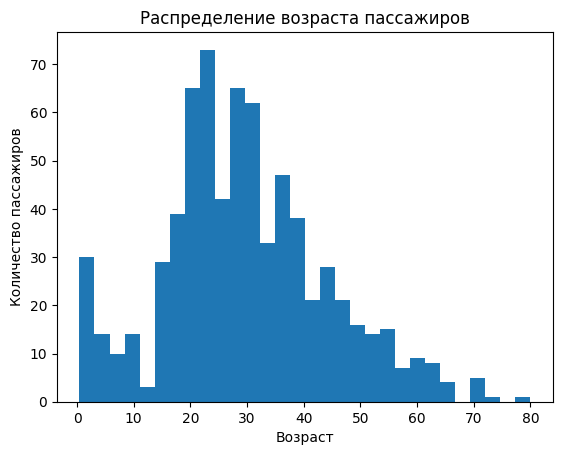

In [26]:
plt.hist(titanic_df['Age'].dropna(), bins=30) # .dropna() удаляет пропущенные значения
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.title("Распределение возраста пассажиров")
plt.show()

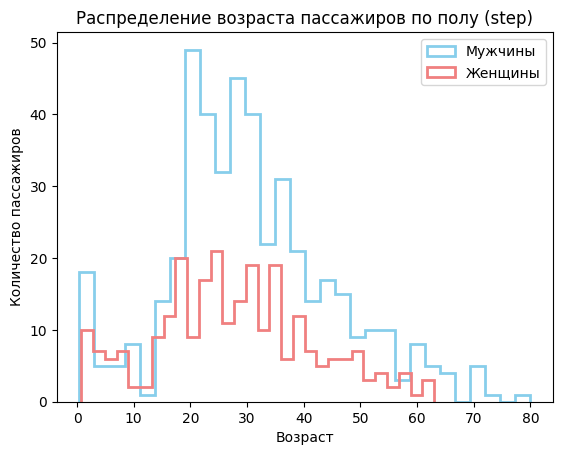

In [27]:
titanic_df['Age'].dropna()

# Фильтруем данные по полу
men_ages = titanic_df[titanic_df['Sex'] == 'male']['Age']
women_ages = titanic_df[titanic_df['Sex'] == 'female']['Age']

# Строим гистограммы
plt.hist(men_ages, bins=30, histtype='step', label='Мужчины', color='skyblue', linewidth=2)
plt.hist(women_ages, bins=30, histtype='step', label='Женщины', color='lightcoral', linewidth=2)

plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.title("Распределение возраста пассажиров по полу (step)")
plt.legend(loc='upper right')
plt.show()

Анализ: Показывает распределение возраста пассажиров на борту “Титаника”. dropna() удаляет пропущенные значения возраста.


Закономерности: Позволяет увидеть, какой возрастной диапазон был наиболее представлен на корабле. Часто наблюдается большое количество детей и молодых людей.

Столбчатая диаграмма выживших и погибших:

In [ ]:
survived_counts = titanic_df['Survived'].value_counts()
colors = ['red', 'green']  # Задаем цвета для "Погиб" и "Выжил"
plt.bar(survived_counts.index, survived_counts.values, color=colors, alpha=0.5)
plt.xticks([0, 1], ['Погиб', 'Выжил'])
plt.xlabel("Статус")
plt.ylabel("Количество пассажиров")
plt.title("Соотношение выживших и погибших")
plt.show()

Анализ: Сравнивает количество выживших и погибших пассажиров.

Закономерности: Дает общее представление о соотношении выживших и погибших.

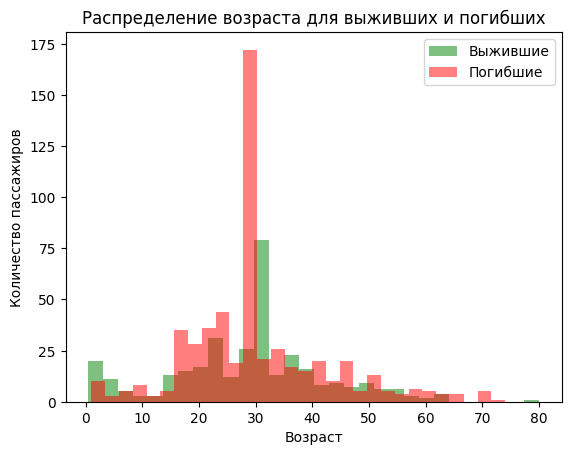

In [30]:
# Заменим значения NaN средними значениями, чтобы не вылетала ошибка
#titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())


# Гистограмма возраста выживших и погибших
plt.hist(titanic_df[titanic_df['Survived'] == 1]['Age'], bins=30, alpha=0.5, label='Выжившие', color='green')
plt.hist(titanic_df[titanic_df['Survived'] == 0]['Age'], bins=30, alpha=0.5, label='Погибшие', color='red')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.title('Распределение возраста для выживших и погибших')
plt.legend()
plt.show()

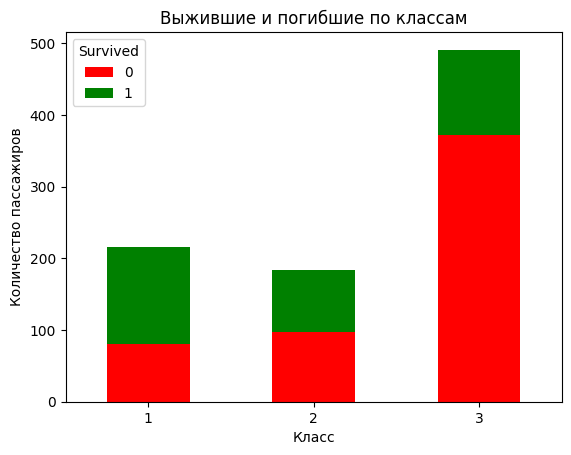

In [31]:
# Считаем количество выживших и погибших в каждом классе
survived_counts = titanic_df.groupby('Pclass')['Survived'].value_counts().unstack()

# Строим stacked bar chart
survived_counts.plot(kind='bar', stacked=True, color=['red', 'green']) #Непосредственно из Pandas

plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.title('Выжившие и погибшие по классам')
plt.xticks(rotation=0) #Чтобы подписи не поворачивались
plt.show()

Анализ: Сравнивает количество выживших и погибших пассажиров  взависимости от класса.

Закономерности: Дает общее представление о соотношении выживших и погибших  в разных классах. Погибло больше в 3 классе

Круговая диаграмма классов пассажиров:

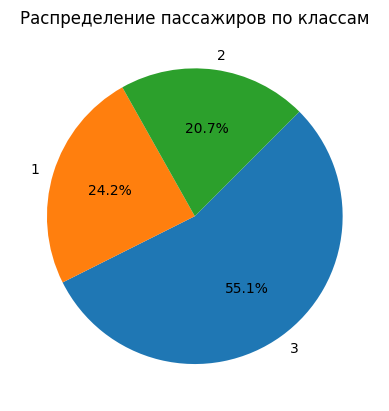

In [32]:
# Считаем количество пассажиров в каждом классе
class_counts = titanic_df['Pclass'].value_counts()

# Круговая диаграмма классов пассажиров
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=45,counterclock=False)
plt.title('Распределение пассажиров по классам')
plt.show()

Анализ: Показывает процентное соотношение пассажиров в каждом классе (1-й, 2-й, 3-й).

Закономерности: Визуализирует социальную структуру пассажиров на корабле. Показывает, какой класс был наиболее многочисленным.

Скрипичная диаграмма возраста по классам

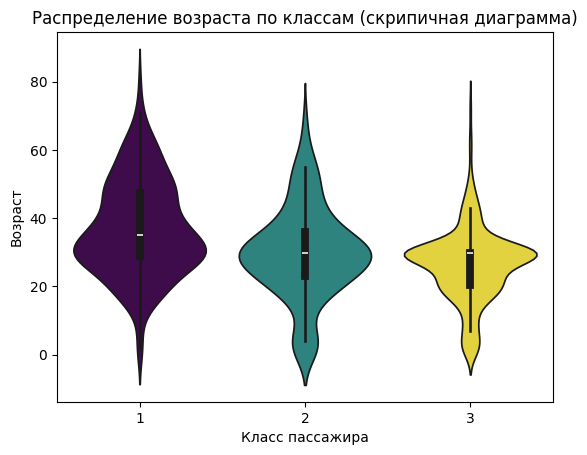

In [33]:
import seaborn as sns
# Скрипичная диаграмма возраста по классам (с использованием Seaborn)
sns.violinplot(x='Pclass', y='Age', data=titanic_df, palette='viridis', hue='Pclass', legend=False)
plt.title('Распределение возраста по классам (скрипичная диаграмма)')
plt.xlabel("Класс пассажира")
plt.ylabel("Возраст")
plt.show()

Анализ: Сравнивает распределение возраста пассажиров в каждом классе.

Закономерности: Показывает, различается ли средний возраст и разброс возраста в разных классах. Обычно в первом классе средний возраст выше.

Столбчатая диаграмма пола пассажиров:

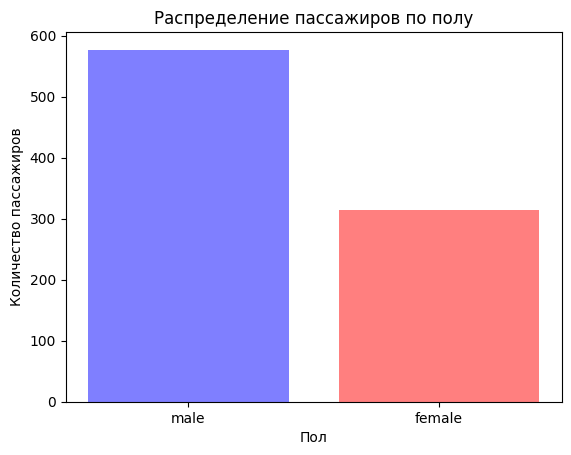

In [34]:
gender_counts = titanic_df['Sex'].value_counts()
colors = ['blue','red']
plt.bar(gender_counts.index, gender_counts.values,color=colors, alpha=0.5)
plt.xlabel("Пол")
plt.ylabel("Количество пассажиров")
plt.title("Распределение пассажиров по полу")
plt.show()

Анализ: Показывает количество мужчин и женщин на борту.

Закономерности: Дает представление о гендерном составе пассажиров.

Гистограмма стоимости билета:

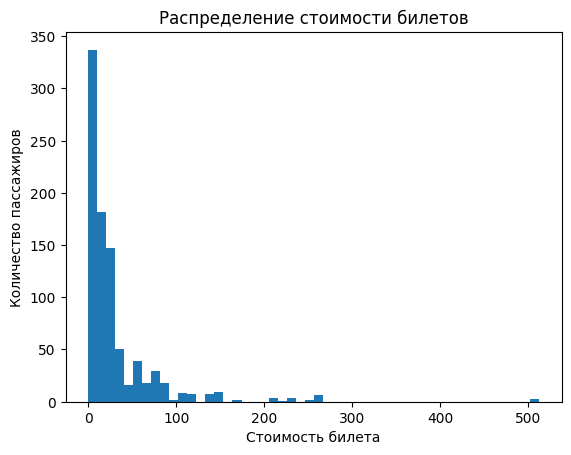

In [35]:
plt.hist(titanic_df['Fare'], bins=50)
plt.xlabel("Стоимость билета")
plt.ylabel("Количество пассажиров")
plt.title("Распределение стоимости билетов")
plt.show()

Анализ: Показывает распределение стоимости билетов.

Закономерности: Позволяет увидеть, какие ценовые категории билетов были наиболее распространены.

Точечная диаграмма: Возраст vs. Стоимость билета:

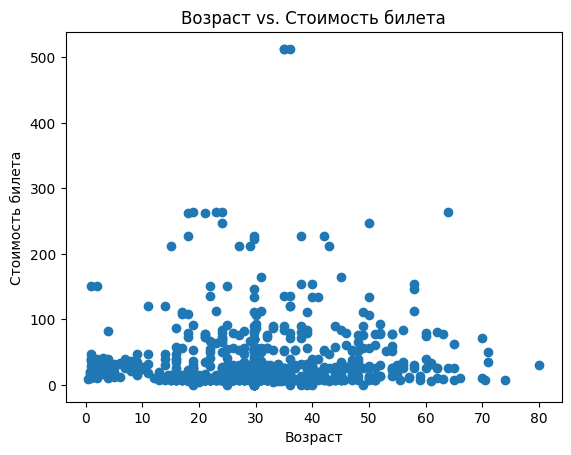

In [36]:
plt.scatter(titanic_df['Age'], titanic_df['Fare'])
plt.xlabel("Возраст")
plt.ylabel("Стоимость билета")
plt.title("Возраст vs. Стоимость билета")
plt.show()

Анализ: Исследует связь между возрастом пассажира и стоимостью его билета.

Закономерности: Можно увидеть, есть ли тенденция, что более дорогие билеты покупали люди определенного возраста.

Столбчатая диаграмма выживших по полу:

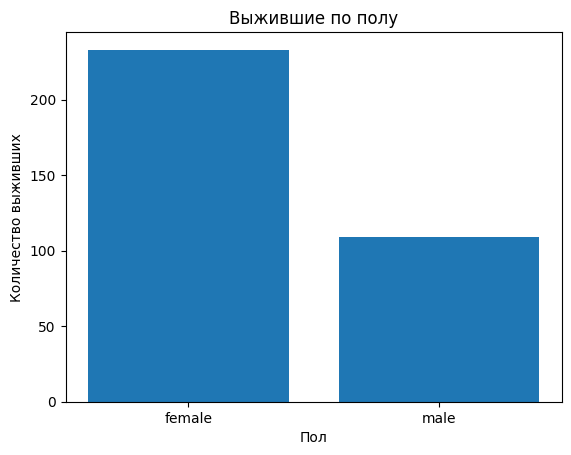

In [37]:
survived_sex = titanic_df.groupby('Sex')['Survived'].sum()
plt.bar(survived_sex.index, survived_sex.values)
plt.xlabel("Пол")
plt.ylabel("Количество выживших")
plt.title("Выжившие по полу")
plt.show()

Анализ: Сравнивает количество выживших мужчин и женщин.

Закономерности: Показывает, какой пол имел больше шансов на выживание (традиционно, женщины имели больше шансов).

**Столбчатая диаграмма выживших по классу:**

In [ ]:
survived_class = titanic_df.groupby('Pclass')['Survived'].sum()
bars= plt.bar(survived_class.index, survived_class.values) # записали в переменную
# создаем цикл проходим по колонкам
colors = ['forestgreen','blue','coral']  # Цвета для каждого столбца
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel("Класс пассажира")
plt.ylabel("Количество выживших")
plt.title("Выжившие по классу")
plt.show()

Анализ: Сравнивает количество выживших в каждом классе.

Закономерности: Показывает, какой класс имел больше шансов на выживание (обычно, первый класс имел больше шансов).

**Диаграмма рассеяния с цветовой кодировкой выживших: Возраст vs. Стоимость билета:**

In [ ]:
plt.scatter(titanic_df['Age'], titanic_df['Fare'], c=titanic_df['Survived'])
plt.xlabel("Возраст")
plt.ylabel("Стоимость билета")
plt.title("Возраст vs. Стоимость билета (выжившие выделены цветом)")
plt.colorbar(label='Выжил (1) / Погиб (0)') # добавляем легенду для цветовой шкалы
plt.show()

Анализ: Исследует связь между возрастом и стоимостью билета, выделяя выживших и погибших разными цветами.

Закономерности: Можно увидеть, были ли какие-то комбинации возраста и стоимости билета, которые повышали или понижали шансы на выживание.

**Гистограмма возраста для выживших и погибших (в одном графике):**

In [ ]:
plt.hist(titanic_df[titanic_df['Survived'] == 1]['Age'].dropna(), bins=30, alpha=0.5, label='Выжившие')
plt.hist(titanic_df[titanic_df['Survived'] == 0]['Age'].dropna(), bins=30, alpha=0.5, label='Погибшие')
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.title("Распределение возраста для выживших и погибших")
plt.legend()
plt.show()

Анализ: Сравнивает распределение возраста для выживших и погибших пассажиров.

Закономерности: Позволяет увидеть, какой возраст имел больше шансов на выживание.

Столбчатая диаграмма количества родственников (SibSp) на борту:

In [ ]:
sibsp_counts = titanic_df['SibSp'].value_counts().sort_index()
plt.barh(sibsp_counts.index, sibsp_counts.values)
plt.xlabel("Количество братьев/сестер/супругов на борту")
plt.ylabel("Количество пассажиров")
plt.title("Распределение количества родственников (SibSp)")
plt.show()

Анализ: Показывает количество пассажиров с разным количеством братьев, сестер и супругов на борту.

Закономерности: Дает представление о том, сколько пассажиров путешествовало в одиночку или с семьей.

**Столбчатая диаграмма количества детей/родителей (Parch) на борту:**

In [ ]:
parch_counts = titanic_df['Parch'].value_counts().sort_index()
plt.bar(parch_counts.index, parch_counts.values)
plt.xlabel("Количество детей/родителей на борту")
plt.ylabel("Количество пассажиров")
plt.title("Распределение количества родственников (Parch)")
plt.show()

Анализ: Показывает количество пассажиров с разным количеством детей и родителей на борту.

Закономерности: Помогает понять, сколько было семей с детьми.

**Боксплот стоимости билета по признаку Embarked (место посадки):**

In [ ]:
titanic_df.boxplot(column='Fare', by='Embarked')
plt.xlabel("Место посадки")
plt.ylabel("Стоимость билета")
plt.title("Распределение стоимости билета по месту посадки")
plt.suptitle('')
plt.show()

Анализ: Сравнивает распределение стоимости билета в зависимости от порта посадки.

Закономерности: Можно увидеть, различалась ли средняя стоимость билетов в разных портах.

**Столбчатая диаграмма: Выжившие vs. Погибшие по Embarked (место посадки):**

In [ ]:
survived_embarked = titanic_df.groupby('Embarked')['Survived'].value_counts().unstack()
survived_embarked.plot(kind='bar', stacked=True)
plt.xlabel("Место посадки")
plt.ylabel("Количество пассажиров")
plt.title("Выжившие и погибшие по месту посадки")
plt.legend(['Погиб', 'Выжил'])
plt.show()

Анализ: Показывает соотношение выживших и погибших в каждом порту посадки.

Закономерности: Помогает понять, влиял ли порт посадки на шансы выживания.

**Гистограмма длинны имени пассажира:**

In [ ]:
titanic_df['NameLength'] = titanic_df['Name'].apply(len)
plt.hist(titanic_df['NameLength'], bins=50)
plt.xlabel("Длина имени")
plt.ylabel("Количество пассажиров")
plt.title("Распределение длины имен пассажиров")
plt.show()

Анализ: Показывает распределение длин имен пассажиров.

Закономерности: Может быть интересно посмотреть, связано ли длина имени с другими признаками, например, классом.

**Столбчатая диаграмма, показывающая количество пассажиров, путешествующих в одиночку и с семьей (SibSp + Parch > 0):**

In [ ]:
titanic_df['IsAlone'] = (titanic_df['SibSp'] + titanic_df['Parch'] == 0).astype(int)
alone_counts = titanic_df['IsAlone'].value_counts()
plt.bar(alone_counts.index, alone_counts.values)
plt.xticks([0, 1], ['С семьей', 'Один'])
plt.xlabel("Статус")
plt.ylabel("Количество пассажиров")
plt.title("Путешествующие в одиночку vs. С семьей")
plt.show()

Анализ: Сравнивает количество пассажиров, путешествующих в одиночку, и количество пассажиров, путешествующих с семьей.

Закономерности: Дает представление о том, сколько людей путешествовало в одиночку.

Боксплот стоимости билета для выживших и погибших:

In [ ]:
titanic_df.boxplot(column='Fare', by='Survived')
plt.xlabel("Выжил (1) / Погиб (0)")
plt.ylabel("Стоимость билета")
plt.title("Распределение стоимости билета для выживших и погибших")
plt.suptitle('')
plt.show()

Анализ: Сравнивает распределение стоимости билета для выживших и погибших.

Закономерности: Показывает, была ли стоимость билета фактором, влияющим на выживание.

In [ ]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)

plt.scatter(titanic_df['Age'], titanic_df['Fare'],
            s=titanic_df['Pclass'] * 50, # Размер зависит от класса (1-й класс - больше)
            c=titanic_df['Survived'],    # Цвет зависит от выживания (0 или 1)
            cmap='RdYlGn',               # Красный-желтый-зеленый cmap
            alpha=0.7,
            edgecolors='black')

plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.title('Возраст vs. Стоимость билета (цвет - выживание, размер - класс)')
plt.colorbar(label='Выжил (1) / Погиб (0)')

# Добавляем легенду для размера
sizes = [1, 2, 3]
labels = ['1st Class', '2nd Class', '3rd Class']
for size, label in zip(sizes, labels):
    plt.scatter([], [], s=size*50, c='gray', label=label, edgecolors='black') #Пустые маркеры
plt.legend(scatterpoints=1, labelspacing=1, title='Класс', bbox_to_anchor=(1.05, 1), loc='upper left') # Размещаем легенду

plt.tight_layout() # чтобы не перекрывалась легенда
plt.show()

# Продвинутые возможности Matplotlib

## 3D-графики

Matplotlib имеет модуль mpl_toolkits.mplot3d, который позволяет создавать трехмерные графики.

### Создание 3D-осей

* *args: Позиционные аргументы, определяющие положение осей в сетке подграфиков. Например, add_subplot(1, 2, 1) создаст одну строку, два столбца, и оси будут расположены в первой ячейке.

* projection: Определяет тип проекции осей. Для 3D-осей всегда должен быть установлен в '3d'. Это ключевой параметр, который сообщает Matplotlib, что вы хотите создать 3D-оси.

* sharex, sharey, sharez: Указывают, с какими другими осями нужно разделить оси X, Y и Z. Это полезно для создания графиков, где нужно синхронизировать масштабы осей.

* label: Метка для осей.

* frameon: Если True, рисуется рамка вокруг осей.

* facecolor: Цвет фона осей.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # для 3D
import numpy as np

# Создаем фигуру и добавляем 3D-оси
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d') # Создание Axes3D -111 означает, что вы создаете одну строку, один столбец и один график

plt.show()

### 3D-точечные диаграммы (scatter3D)

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Генерируем случайные данные
n = 100
x = np.random.rand(n)
y = np.random.rand(n)
z = np.random.rand(n)
colors = np.random.rand(n)
sizes = 50 * np.random.rand(n)

# Создаем точечную диаграмму
ax.scatter(x, y, z, c=colors, s=sizes, cmap='viridis')  #cmap задает цветовую схему

# Настройка меток осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title("3D Точечная диаграмма")
plt.show()

### 3D-линейные графики (plot3D)

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Создаем данные для спирали
t = np.linspace(0, 10*np.pi, 500)
x = np.sin(t)
y = np.cos(t)
z = t

# Строим 3D-линейный график
ax.plot(x, y, z)

# Настройка меток осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D Линейный график")
plt.show()

### 3D-поверхности (plot_surface)

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Создаем сетку координат
num1 = np.arange(-5, 5, 0.1)
num2 = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(num1, num2)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Строим поверхность
ax.plot_surface(X, Y, Z, cmap='viridis')

# Настройка меток осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D Поверхность")
plt.show()

### 3D-контурные графики (contourf)

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Создаем сетку координат (как и в примере с plot_surface)
num1 = np.arange(-5, 5, 0.1)
num2 = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(num1, num2)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Строим контурный график
ax.contourf(X, Y, Z, zdir='z', offset=-2, cmap='viridis') # zdir указывает ось, на которой отображать контуры, offset - смещение

# Настройка меток осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(-2, 1) #  Устанавливаем пределы для оси Z

plt.title("3D Контурный график")
plt.show()


### Настройка внешнего вида 3D-графиков

Настройка внешнего вида 3D-графиков включает в себя изменение цветов, углов обзора, масштабов осей и добавление легенды.

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Данные (как в примере с plot_surface)
num1 = np.arange(-5, 5, 0.1)
num2 = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(num1, num2)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Поверхность с настройками
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm',
                       linewidth=0, antialiased=False)

# Настройка углов обзора (elev - высота, azim - азимут)
ax.view_init(elev=30, azim=45)

# Добавляем цветовую панель (colorbar)
fig.colorbar(surf, shrink=0.5, aspect=5)

# Настройка меток осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title("3D Поверхность с настройками")
plt.show()

**Основные моменты:**

* Обязательно импортируйте Axes3D из mpl_toolkits.mplot3d.
* При создании осей используйте projection='3d', чтобы указать, что вы хотите создать 3D-оси.
* Используйте методы объекта ax для настройки внешнего вида и поведения 3D-осей.
* Помните, что 3D-графики могут быть сложными для восприятия. Настраивайте угол обзора, цветовые карты и другие параметры, чтобы сделать график максимально понятным.

## Анимация (matplotlib.animation)

Matplotlib предоставляет модуль matplotlib.animation для создания анимаций.

**Основы анимации**
Анимация создается путем последовательного обновления содержимого графика.

**Основные компоненты:**
* Figure: Фигура, содержащая график.
* Axes: Область рисования.
* Для создания анимаций в Matplotlib используются два основных класса:

 * FuncAnimation: Создает анимацию, многократно вызывая пользовательскую функцию. Это наиболее гибкий и распространенный способ создания анимаций.

 * ArtistAnimation: Создает анимацию из последовательности уже существующих объектов Artist (например, линий, точек, изображений).



### FuncAnimation

**FuncAnimation** создает анимацию, вызывая функцию для каждого кадра.

* fig: Обязательный параметр. Объект Figure, на котором будет отображаться анимация.

* func: Обязательный параметр. Функция, которая будет вызываться для каждого кадра анимации. Эта функция должна принимать как минимум один аргумент – номер кадра. Функция должна изменять данные на графике и возвращать последовательность объектов Artist, которые были изменены.

* frames: Определяет, сколько кадров будет в анимации и какие значения будут передаваться в функцию func. Может быть:

 * None: Анимация будет продолжаться бесконечно (пока не будет остановлена вручную).
 * Целым числом: Задает количество кадров анимации. Функция func будет вызываться с номерами кадров от 0 до frames - 1.
 * Итерируемым объектом (например, списком, генератором): Задает последовательность значений, которые будут передаваться в функцию func в качестве аргумента кадра.
* init_func: Функция, которая вызывается один раз перед началом анимации для инициализации графика. Эта функция должна возвращать последовательность объектов Artist, которые будут отображаться в первом кадре анимации. Если None, первый кадр будет создан путем вызова функции func с аргументом 0.

* fargs: Кортеж дополнительных аргументов, которые будут передаваться в функцию func после аргумента кадра.

* save_count: Максимальное количество кадров, которое будет сохранено в кэше для воспроизведения анимации в обратном порядке.

* cache_frame_data: Логическое значение, указывающее, следует ли кэшировать данные каждого кадра. Кэширование может ускорить воспроизведение, но требует дополнительной памяти.

* **kwargs: Дополнительные аргументы ключевого слова, которые передаются в базовый класс TimedAnimation. Некоторые важные kwargs:

 * interval: Задержка между кадрами в миллисекундах.
 * repeat: Если True, анимация будет повторяться после завершения.
 * repeat_delay: Задержка перед повторным воспроизведением анимации (в миллисекундах).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation  # модуль для анимации
import numpy as np

# Создаем фигуру и оси
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)

# Функция для инициализации анимации (обязательна)
def init():
    line.set_data([], [])
    return (line,)

# Функция для обновления каждого кадра
def animate(i):
    x = np.linspace(0, 10, 1000)
    y = np.sin(x + i/10.0)  # i/10.0 делает анимацию более медленной
    line.set_data(x, y)
    return (line,)

# Создаем анимацию
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=200, blit=True) # frames - количество кадров

plt.title("Анимация синусоиды")
plt.show()

### ArtistAnimation

**ArtistAnimation** создает анимацию из последовательности уже созданных объектов (Artist).

Это подходит, когда каждый кадр можно представить как отдельный набор графических элементов.

* fig: Обязательный параметр. Объект Figure, на котором будет отображаться анимация.

* artists: Обязательный параметр. Список (или итерируемый объект) списков объектов Artist. Каждый внутренний список представляет один кадр анимации.

* repeat_delay: Задержка перед повторным воспроизведением анимации (в миллисекундах).

* repeat: Если True, анимация будет повторяться после завершения.

* interval: Задержка между кадрами в миллисекундах.

* blit: Если True, используется blitting для ускорения отрисовки анимации. Blitting означает, что перерисовываются только те части графика, которые изменились между кадрами.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots()
ims = []  # Список кадров анимации

for i in range(50):
    x = np.arange(0, 2*np.pi, 0.1)
    y = np.sin(x + i/10.0)
    line, = ax.plot(x, y, "b-")
    ims.append([line]) # Важно добавлять список объектов для каждого кадра

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000) # interval - задержка между кадрами в мс, repeat_delay - задержка после окончания анимации

plt.title("ArtistAnimation")
plt.show()

### Обновление данных в анимации

Анимация может использоваться для визуализации изменения данных во времени. Например, можно анимировать изменение распределения данных, динамику физических процессов или машинное обучение.

### Сохранение анимации в файл

Для сохранения анимации используется метод save(). Необходим установленный кодек, например, ffmpeg или imagemagick.

* filename: Обязательный параметр. Имя файла, в который будет сохранена анимация. Расширение файла определяет формат анимации (например, 'animation.mp4', 'animation.gif').

* writer: Объект MovieWriter, используемый для записи анимации. Если None, Matplotlib попытается автоматически выбрать подходящий writer на основе расширения файла. Вы можете явно указать writer, например, 'ffmpeg' или 'imagemagick'. Для этого может потребоваться установка соответствующего кодека.

* fps: Количество кадров в секунду. Влияет на скорость воспроизведения анимации.

* dpi: Разрешение анимации в точках на дюйм (DPI).

* codec: Кодек, используемый для сжатия видео (например, 'libx264').

* bitrate: Битрейт видео (в килобитах в секунду).

* extra_args: Список дополнительных аргументов, которые передаются в writer.

* metadata: Словарь метаданных, которые будут добавлены в файл анимации.

* savefig_kwargs: Словарь дополнительных аргументов, которые передаются в fig.savefig для сохранения каждого кадра.

In [ ]:
# Установите ffmpeg:  conda install -c conda-forge ffmpeg  или  sudo apt-get install ffmpeg
# Или imagemagick: conda install -c conda-forge imagemagick


ani.save("sine_wave.gif", writer='imagemagick', fps=30)

In [ ]:
ani.save("sine_wave.mp4", writer='ffmpeg', fps=30) # fps - кадры в секунду

# Виджеты

для интерактивного управления графиками Matplotlib. ipywidgets позволяет создавать элементы управления (слайдеры, выпадающие списки, кнопки и т.д.) в Jupyter Notebook и связывать их с параметрами графиков, делая визуализацию интерактивной.

In [ ]:
#Установленные библиотеки matplotlib и ipywidgets. Если у вас их нет, установите:
pip install matplotlib ipywidgets
jupyter nbextension enable --py widgetsnbextension

Можно использовать различные виджеты

(**IntSlider, FloatSlider, Dropdown, Checkbox и др.**)

для управления любыми параметрами графика: цвет, стиль линии, пределы осей, и т.д.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

# Создаем фигуру и оси
fig, ax = plt.subplots(1, 1)
ax.set_ylim([-1.1, 1.1]) #Фиксируем предел графика
fig.set_size_inches(8, 4)

# Функция для обновления графика
def update_sin(w):
    ax.clear()
    ax.set_ylim([-1.1, 1.1]) #Фиксируем предел графика
    x = np.linspace(0, 10, 1000)
    ax.plot(x, np.sin(w * x))
    plt.xlabel('x')
    plt.ylabel('sin(x)')
    plt.title('Интерактивная синусоида')
    plt.grid(True) #Включаем сетку

# Создаем слайдер
w_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description='Частота:'
)

# Связываем слайдер с функцией обновления графика
interact(update_sin, w=w_slider)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

# Создаем фигуру и оси
fig, ax = plt.subplots(1, 1)
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
fig.set_size_inches(8, 4)

# Функция для обновления графика
def update_gauss(sigma):
    ax.clear()
    ax.set_xlim([-5, 5])
    ax.set_ylim([-5, 5])
    x = np.linspace(-5, 5, 1000)
    gauss = np.exp(-(x**2) / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #Нормальное распределение
    ax.plot(x, gauss)
    plt.xlabel('x')
    plt.ylabel('Плотность вероятности')
    plt.title('Интерактивное нормальное распределение')
    plt.grid(True)

# Создаем слайдер
sigma_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=3.0,
    step=0.1,
    description='Sigma:'
)

# Связываем слайдер с функцией обновления графика
interact(update_gauss, sigma=sigma_slider)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

# Создаем фигуру и оси
fig, ax = plt.subplots(1, 1)
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
fig.set_size_inches(8, 4)

# Функция для обновления графика
def update_function(func_name):
    ax.clear()
    ax.set_xlim([0, 10])
    ax.set_ylim([0, 10])
    x = np.linspace(0, 10, 1000)
    if func_name == 'sin':
        y = np.sin(x)
    elif func_name == 'cos':
        y = np.cos(x)
    elif func_name == 'tan':
        y = np.tan(x)
    else:
        y = x**2
    ax.plot(x, y)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Интерактивный выбор функции')
    plt.grid(True)

# Создаем выпадающий список
function_dropdown = widgets.Dropdown(
    options=['sin', 'cos', 'tan', 'x^2'],
    value='sin',
    description='Функция:'
)

# Связываем выпадающий список с функцией обновления графика
interact(update_function, func_name=function_dropdown)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

# Создаем фигуру и оси
fig, ax = plt.subplots(1, 1)
ax.set_xlim([0, 10])
ax.set_ylim([-2, 2])
fig.set_size_inches(8, 4)

# Функция для обновления графика
def update_checkbox(show_grid):
    ax.clear()
    ax.set_xlim([0, 10])
    ax.set_ylim([-2, 2])
    x = np.linspace(0, 10, 1000)
    ax.plot(x, np.sin(x))
    plt.xlabel('x')
    plt.ylabel('sin(x)')
    plt.title('Интерактивное отображение сетки')
    if show_grid:
        plt.grid(True)
    else:
        plt.grid(False)

# Создаем флажок
grid_checkbox = widgets.Checkbox(
    value=True,
    description='Отображать сетку:'
)

# Связываем флажок с функцией обновления графика
interact(update_checkbox, show_grid=grid_checkbox)

plt.show()

In [ ]:
# Функция для обновления графика
def update_title(title):
    ax.clear()
    ax.set_xlim([0, 10])
    ax.set_ylim([-2, 2])
    x = np.linspace(0, 10, 1000)
    ax.plot(x, np.sin(x))
    plt.xlabel('x')
    plt.ylabel('sin(x)')
    plt.title(title)
    plt.grid(True)

# Создаем текстовое поле
title_text = widgets.Text(
    value='Интерактивный график',
    description='Заголовок:'
)

# Связываем текстовое поле с функцией обновления графика
interact(update_title, title=title_text)

plt.show()

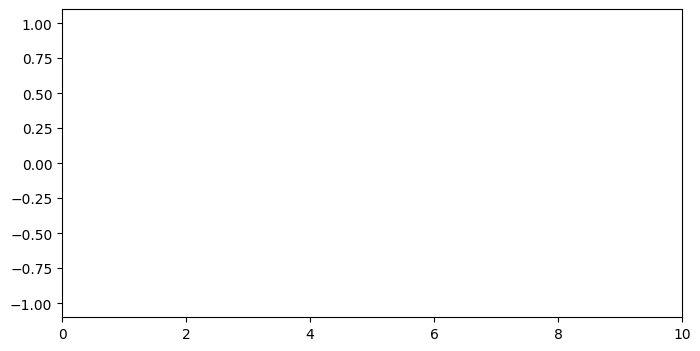

interactive(children=(FloatSlider(value=1.0, description='Амплитуда:', max=3.0, min=0.1), Button(description='…

In [ ]:


import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

# Создаем фигуру и оси
fig, ax = plt.subplots(1, 1)
ax.set_xlim([0, 10])
ax.set_ylim([-1.1, 1.1])
fig.set_size_inches(8, 4)

# Функция для обновления графика
def update_button(amplitude):
    ax.clear()
    ax.set_xlim([0, 10])
    ax.set_ylim([-1.1, 1.1])
    x = np.linspace(0, 10, 1000)
    ax.plot(x, amplitude * np.sin(x))
    plt.xlabel('x')
    plt.ylabel('sin(x)')
    plt.title('Интерактивный график с кнопкой')
    plt.grid(True)

# Создаем слайдер
amplitude_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=3.0,
    step=0.1,
    description='Амплитуда:'
)

# Создаем интерактивный объект с ручным обновлением
interactive_plot = interact_manual(update_button, amplitude=amplitude_slider) #Uncomment
interactive_plot.widget.children[1].description = 'Обновить график' #Меняем текст кнопки

plt.show()

### Обработка событий виджетов

Можно создавать пользовательские функции для обработки событий виджетов, например, для изменения цвета графика при нажатии кнопки.

## Стили и темы

### Встроенные стили Matplotlib

Matplotlib имеет встроенные стили, которые можно использовать для изменения внешнего вида графиков.

**Некоторые из наиболее популярных встроенных стилей:**

* 'default': Стиль по умолчанию.
* 'classic': Стиль, имитирующий внешний вид Matplotlib 1.x.
* 'Solarize_Light2': Светлый стиль с акцентом на читаемость.
* 'dark_background': Темный стиль, подходящий для темных тем оформления.
* 'bmh': Стиль, имитирующий внешний вид графиков в блоге “Beautiful Math, Horrible Graphs”.
* 'ggplot': Стиль, имитирующий внешний вид графиков в R-пакете ggplot2.
* 'seaborn' и другие стили Seaborn: Matplotlib интегрируется с библиотекой Seaborn, которая предоставляет собственные стили графиков.

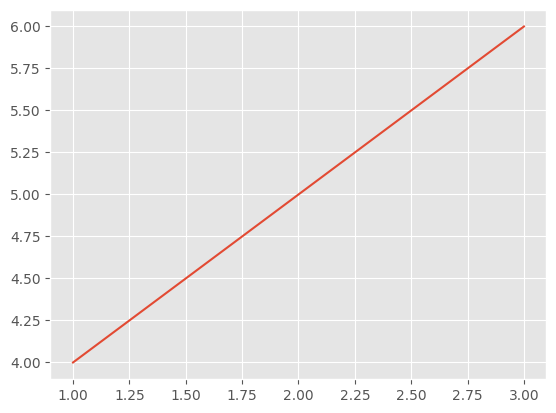

In [3]:
plt.style.use('ggplot')  # Применяем стиль 'ggplot'

# Теперь все графики будут отображаться в стиле 'ggplot'
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

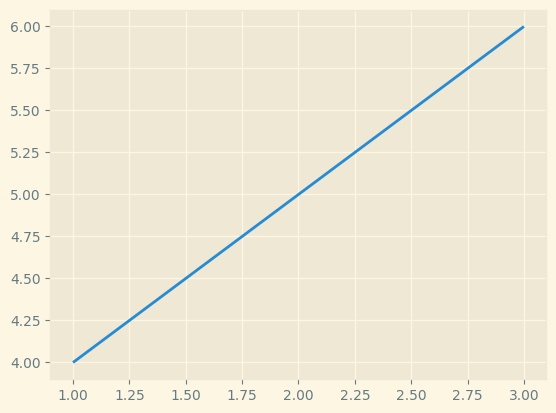

In [4]:
with plt.style.context('Solarize_Light2'):
    # Графики, созданные внутри этого блока, будут отображаться в стиле 'Solarize_Light2'
    plt.plot([1, 2, 3], [4, 5, 6])
    plt.show()

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


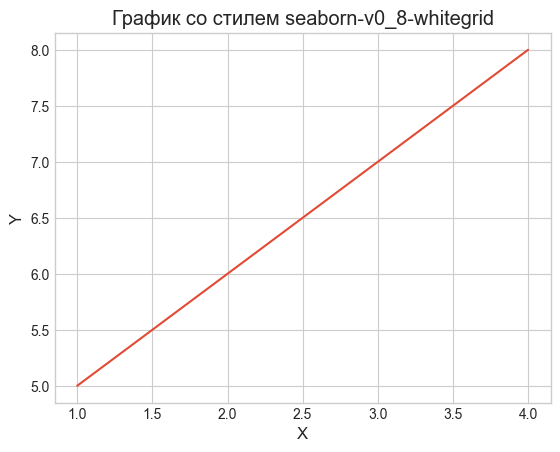

In [5]:
import matplotlib.pyplot as plt

# Выводим список доступных стилей
print(plt.style.available)

# Применяем стиль
plt.style.use('seaborn-v0_8-whitegrid') # или любой другой стиль из списка

# Создаем график (пример)
plt.plot([1, 2, 3, 4], [5, 6, 7, 8])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("График со стилем seaborn-v0_8-whitegrid")
plt.show()

### Создание пользовательских стилей

Можно создавать собственные стили, определяя параметры графиков в файле .mplstyle.

Файл стиля представляет собой текстовый файл, содержащий параметры Matplotlib в формате **parameter: value.**

Пример файла **my_style.mplstyle**

In [ ]:
axes.facecolor: blue
axes.edgecolor: black
axes.linewidth: 1.2
axes.grid: True
grid.color: lightgray
grid.linestyle: --
xtick.color: black
ytick.color: black
font.family: serif
font.size: 12

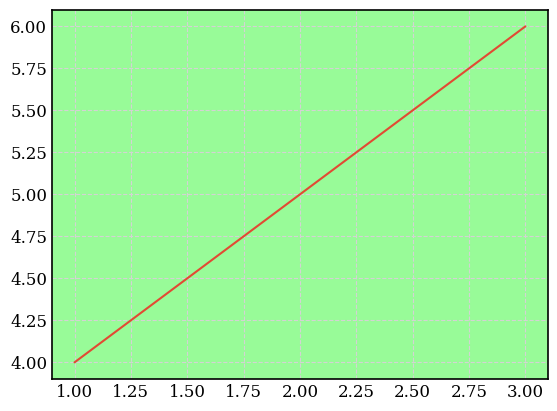

In [11]:
import matplotlib.pyplot as plt

plt.style.use('my_style.mplstyle')  # Применяем пользовательский стиль

plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

**Настройка параметров Matplotlib напрямую:**

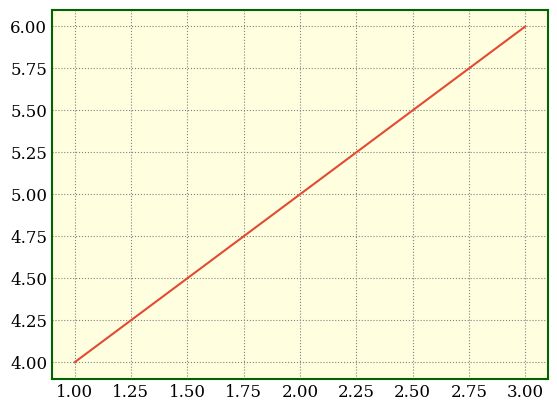

In [12]:
# Настраиваем параметры по умолчанию
plt.rcParams['axes.facecolor'] = 'lightyellow'
plt.rcParams['axes.edgecolor'] = 'darkgreen'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = ':'

# Теперь все графики будут отображаться с этими настройками
plt.plot([1, 2, 3], [4, 5, 6])
plt.grid(True)
plt.show()

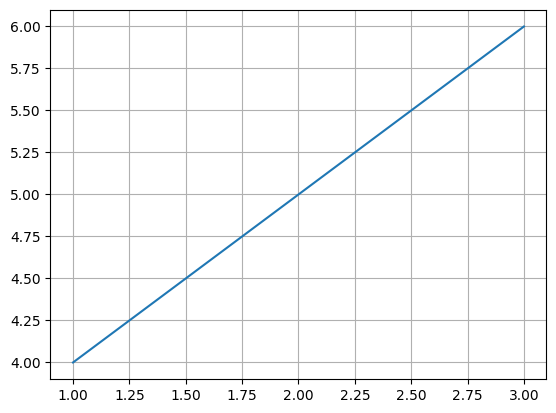

In [13]:
# возврат назад к стандарту
plt.rcdefaults()


# Теперь все графики будут отображаться с этими настройками
plt.plot([1, 2, 3], [4, 5, 6])
plt.grid(True)
plt.show()

## Продвинутая настройка осей

### Пользовательские тики (ticks) и метки

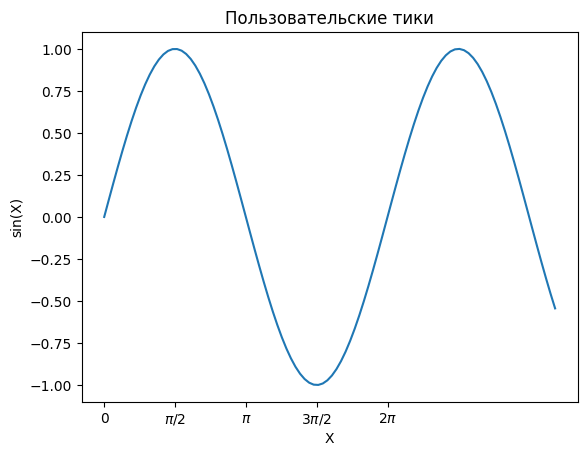

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)

# Устанавливаем пользовательские тики
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']) # используем LaTeX для красивых меток

plt.xlabel("X")
plt.ylabel("sin(X)")
plt.title("Пользовательские тики")
plt.show()

### Логарифмические оси

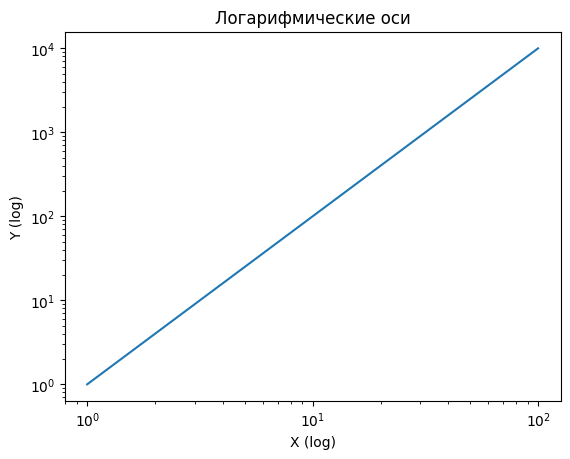

In [15]:
x = np.linspace(1, 100, 100)
y = x**2

plt.plot(x, y)
plt.xscale('log') # логарифмическая шкала для оси X
plt.yscale('log') # логарифмическая шкала для оси Y

plt.xlabel("X (log)")
plt.ylabel("Y (log)")
plt.title("Логарифмические оси")
plt.show()

## Продвинутые цветовые карты (Colormaps)

Цветовые карты позволяют отображать значения данных с помощью различных цветов, что может помочь выделить важные закономерности.

#### Использование различных цветовых карт

Matplotlib предоставляет множество встроенных цветовых карт (sequential, diverging, qualitative).

**Список доступных цветовых карт**
print(plt.colormaps())

**Типы цветовых карт:**

* Sequential (последовательные): Цветовые карты, в которых цвета изменяются в непрерывном порядке от одного значения к другому. Подходят для отображения данных, которые изменяются в одном направлении (например, температура, высота).

* Diverging (расходящиеся): Цветовые карты, в которых два разных цвета расходятся от центрального значения (обычно 0). Подходят для отображения данных, которые имеют положительные и отрицательные значения или отклонения от некоторого среднего значения.

* Qualitative (качественные): Цветовые карты, в которых используются дискретные цвета для представления категориальных данных. Важно, чтобы цвета были достаточно различимы, чтобы их можно было легко идентифицировать.

**Пояснения:**

* plt.imshow(Z, ...): Отображает данные в виде изображения.
 * extent: Задает границы осей X и Y.
 * origin='lower': Указывает, что начало координат (0, 0) находится в нижнем левом углу.
 * cmap: Задает цветовую карту.
 * interpolation: Задает метод интерполяции для сглаживания изображения. 'nearest' означает, что каждый пиксель отображается одним цветом без интерполяции.
* plt.colorbar(label='...'): Добавляет цветовую шкалу (colorbar) к графику, показывающую соответствие между цветами и значениями данных.

In [16]:
# Создаем данные
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))


**Sequential:**

* 'viridis': Цветовая карта по умолчанию в Matplotlib. Обеспечивает хорошую различимость цветов и подходит для большинства случаев.
* 'magma': Цветовая карта, которая хорошо подходит для отображения данных в оттенках серого.
* 'inferno': Цветовая карта, которая хорошо подходит для выделения высоких значений.
* 'plasma': Цветовая карта, которая хорошо подходит для отображения данных с высокой детализацией.
* 'cividis': Цветовая карта, разработанная для людей с нарушением цветового зрения.
* 'Greens', 'Blues', 'Reds', 'Greys': Однотонные цветовые карты.

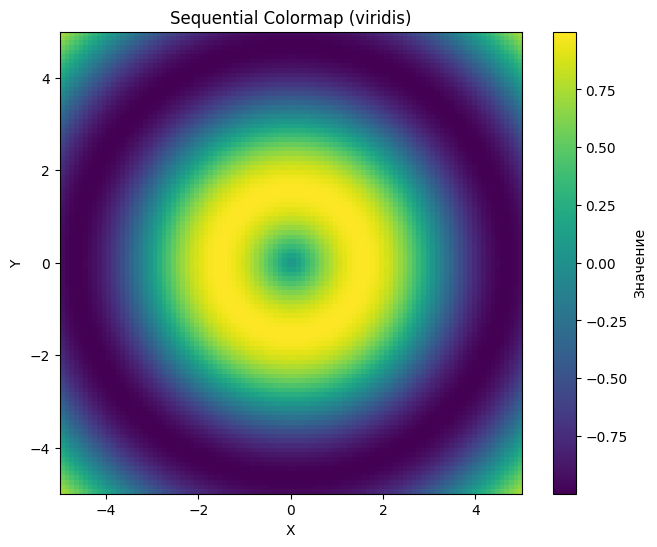

In [17]:
# 1. Sequential colormap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-5, 5, -5, 5], origin='lower', cmap='viridis') #extent задает границы по осям
plt.colorbar(label='Значение')
plt.title('Sequential Colormap (viridis)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

**Diverging:**

* 'coolwarm': Цветовая карта, которая переходит от синего к красному через белый. Подходит для отображения данных с положительными и отрицательными значениями.
* 'RdBu': Цветовая карта, которая переходит от красного к синему через белый.
* 'PiYG': Цветовая карта, которая переходит от розового к зеленому через белый.
* 'BrBG': Цветовая карта, которая переходит от коричневого к зеленому через белый.

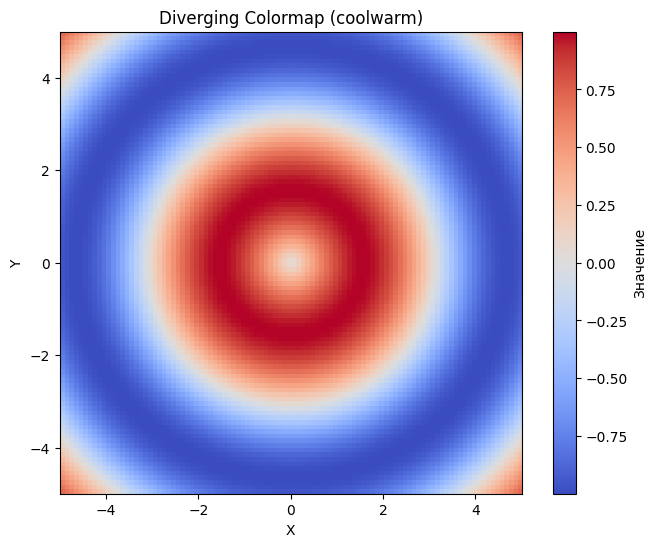

In [18]:
# 2. Diverging colormap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-5, 5, -5, 5], origin='lower', cmap='coolwarm')
plt.colorbar(label='Значение')
plt.title('Diverging Colormap (coolwarm)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

**Qualitative:**

* 'tab10': Цветовая карта, содержащая 10 различных цветов. Подходит для отображения категориальных данных с небольшим количеством категорий.
* 'tab20': Цветовая карта, содержащая 20 различных цветов.
* 'Set1', 'Set2', 'Set3': Наборы качественных цветовых карт.
* 'Paired': Цветовая карта, в которой цвета сгруппированы по парам.

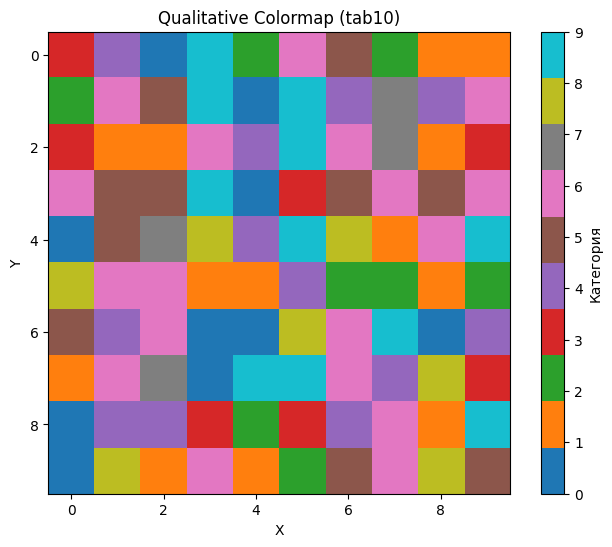

In [20]:
# 3. Qualitative colormap
data = np.random.randint(0, 10, size=(10, 10))
plt.figure(figsize=(8, 6))
plt.imshow(data, cmap='tab10', interpolation='nearest') #interpolation влияет на отображение границ
plt.colorbar(label='Категория')
plt.title('Qualitative Colormap (tab10)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

**Выбор подходящей цветовой карты:**

Выбор подходящей цветовой карты зависит от типа данных, которые вы хотите визуализировать, и от того, какую информацию вы хотите подчеркнуть.

**Для числовых данных:** Используйте sequential или diverging цветовые карты.

**Для категориальных данных:** Используйте qualitative цветовые карты.

Учитывайте особенности восприятия цветов: Избегайте использования цветовых карт, которые могут быть сложными для людей с нарушением цветового зрения.
Экспериментируйте с разными цветовыми картами: Попробуйте разные цветовые карты, чтобы найти ту, которая лучше всего подходит для ваших данных.

**Дополнительные параметры:**

* norm: Объект matplotlib.colors.Normalize, который определяет, как значения данных отображаются на цвета цветовой карты. Позволяет задавать минимальное и максимальное значения для цветовой карты, а также использовать нелинейное масштабирование.
* alpha: Прозрачность цветовой карты.
* interpolation: Метод интерполяции для сглаживания изображения (например, 'nearest', 'bilinear', 'bicubic').
* vmin и vmax: Минимальное и максимальное значения для цветовой карты. Значения данных, выходящие за эти пределы, будут отображаться цветами, соответствующими минимальному и максимальному значениям цветовой карты.

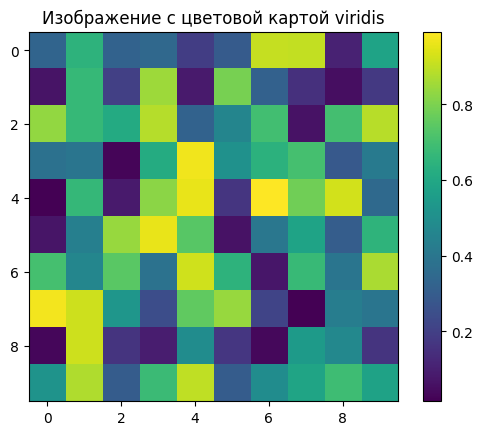

In [21]:
data = np.random.rand(10, 10)

plt.imshow(data, cmap='viridis') # используем viridis цветовую карту
plt.colorbar()  # добавляем цветовую шкалу
plt.title("Изображение с цветовой картой viridis")
plt.show()

In [22]:
import seaborn as sns
correlation_matrix = titanic_df.corr(numeric_only=True) # Убираем предупреждение о нечисловых типах
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm") # annot - показывать значения корреляции
plt.title("Тепловая карта корреляции признаков")
plt.show()

NameError: name 'titanic_df' is not defined

Анализ: Показывает коэффициенты корреляции между числовыми признаками.
Закономерности: Позволяет выявить, какие признаки сильно связаны друг с другом (положительно или отрицательно).

### Создание пользовательских цветовых карт

Можно создавать собственные цветовые карты с использованием **LinearSegmentedColormap.**

**Примеры применения продвинутых возможностей**

Визуализация траекторий движения частиц в трехмерном пространстве (3D-графики, анимация).

Создание интерактивного графика, позволяющего пользователю фильтровать данные по различным критериям (интерактивные графики).

Визуализация результатов кластеризации с использованием различных цветовых карт (цветовые карты).

Анимация изменения модели машинного обучения в процессе обучения (анимация).